# Task 01 | Lesson 05

In [1]:
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.append(project_root)
print(f"Đã thêm vào path: {project_root}")

Đã thêm vào path: d:\Practical-Lesson\ds210-deep-learning\lesson-05


In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
import torch
from functools import partial
import matplotlib.pyplot as plt
import seaborn as sns

import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from src.model01 import TransformerClassifier
from src.data_module import TextDataset, collate_fn, Vocabulary
from tqdm import tqdm

## 1. Preparation

In [3]:
BATCH_SIZE = 32
device = 'cuda'

### 1.1. Vocabualary and Dataset

In [ ]:
text_column = [pd.read_json('../data/UIT_ViOCD/train.json', orient = 'index')['review'].to_list()]
targets = list(set(pd.read_json('../data/UIT_ViOCD/train.json', orient = 'index')['domain'].to_list()))

print(f'First 5 text rows : {text_column[:5]}')
print(f'All label values  : {targets}')

First 5 text rows : [['gói hàng cẩn thận . chơi pubg với liên quân mượt với giá như này thì quá tốt', 'mình góp ý thật nhé . . đừng bắt phải đăng nhập zalo nữa mình muốn tải nhạc mà không được lấy lại tôi không zalo thì gửi tin nhắn mất tiền được mã kích hoạt lại không chính xác . . mình thấy 10 ngưòi thì họ khó chịu cả 10 . . lập trình viên viết ra ứng dụng ngày càng dễ sử dụng đằng này càng ngày lại càng phức tạp và . . . bài đánh giá đầy đủ', 'máy khá đẹp , pin trâu vân tay nhạy nhận diện khuôn mặt nhanh nói chung ổn . tuy chơi game fre fire bị chậm khung hình không mượt lắm nhưng với giá giẫm ngày 1111 được ad mã giảm giá 200k còn hơn 2tr6 thì vậy là ngon rồi', 'một mớ lỗi : không xem lại được bài test , không hiện link ( ví dụ như là youtube khi chia sẻ ) không copy được từ không biết để d

#### 1.1.1. Vocabualary

In [5]:
from itertools import islice

vocab = Vocabulary(2)
vocab.build_vocabulary(text_column)
print(list(islice(vocab.stoi.items(), 5)))

[('<PAD>', 0), ('<UNK>', 1), ('hàng', 2), ('cẩn', 3), ('thận', 4)]


In [6]:
le = LabelEncoder()
encoded_targets = le.fit_transform(targets)
print(encoded_targets)

[1 0 2 3]


In [7]:
print(f"Số lượng domain thực tế: {len(le.classes_)}")
print(f"Danh sách domain: {le.classes_}")

Số lượng domain thực tế: 4
Danh sách domain: ['app' 'cosmetic' 'fashion' 'mobile']


#### 1.1.2. Dataloader

In [ ]:
train_df = TextDataset(
    '../data/UIT_ViOCD/train.json',
    vocab,
    le,
    text_column='review',
    label_column='domain'
)
dev_df = TextDataset(
    '../data/UIT_ViOCD/dev.json',
    vocab,
    le,
    text_column='review',
    label_column='domain'
)
test_df = TextDataset(
    '../data/UIT_ViOCD/test.json',
    vocab,
    le,
    text_column='review',
    label_column='domain'
)

In [9]:
collate_p = partial(collate_fn, pad_idx=vocab.pad_index)

train_loader = DataLoader(
    train_df,
    batch_size = BATCH_SIZE,
    shuffle = True,
    collate_fn=collate_p
)
dev_loader = DataLoader(
    dev_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_p
)
test_loader = DataLoader(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_p
)

### 1.2. Model

In [10]:
model = TransformerClassifier(
    vocab_size=len(vocab.stoi),
    d_model=128,
    nhead=4,
    num_layers=3,
    num_classes=len(le.classes_),
    max_len=300,
    # enable_nested_tensor=False
)

model = model.to(device)
print(model)

TransformerClassifier(
  (embedding): Embedding(3318, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout

## 2. Training

### 2.1. Functions

In [11]:
def evaluate(model, dataloader, criterion, device, pad_idx):
    model.eval() 
    epoch_loss = 0
    epoch_acc = 0
    total_samples = 0
    correct_samples = 0
    
    with torch.no_grad(): 
        for src, targets in dataloader:
            src, targets = src.to(device), targets.to(device)

            src_key_padding_mask = (src == pad_idx)
            outputs = model(src, src_key_padding_mask=src_key_padding_mask)
            
            loss = criterion(outputs, targets)

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += targets.size(0)
            correct_samples += (predicted == targets).sum().item()
            
    avg_loss = epoch_loss / len(dataloader)
    avg_acc = correct_samples / total_samples
    
    return avg_loss, avg_acc

In [ ]:
def train_epoch(model, train_loader, optimizer, criterion, device, pad_idx, epoch_index):
    model.train()
    running_loss = 0.0
    correct_samples = 0
    total_samples = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch_index+1}", leave=False)
    
    for src, targets in progress_bar:
        src = src.to(device)
        targets = targets.to(device)
        src_key_padding_mask = (src == pad_idx)
        
        optimizer.zero_grad()

        outputs = model(src, src_key_padding_mask=src_key_padding_mask)
        
        loss = criterion(outputs, targets)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += targets.size(0)
        correct_samples += (predicted == targets).sum().item()
        
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        
    return running_loss / len(train_loader), correct_samples / total_samples

In [16]:
import copy

def train(model, train_loader, dev_loader, optimizer, criterion, device, vocab, epochs=50, save_path='best_model.pth', patience = 20):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    count_patience = 0
    
    best_val_loss = float('inf')
    best_model_state = None
    pad_idx = vocab.pad_index
    
    print(f"Bắt đầu huấn luyện trên thiết bị: {device}")
    print("-" * 60)

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device, pad_idx, epoch
        )
        val_loss, val_acc = evaluate(model, dev_loader, criterion, device, pad_idx)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            saved_msg = f"--> Đã lưu Best Model (Val Loss: {val_loss:.4f})"
            count_patience = 0
        else:
            saved_msg = ""
            count_patience += 1
            
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} {saved_msg}")
              
    print("-" * 60)
    print("Huấn luyện hoàn tất.")

    if best_model_state:
        model.load_state_dict(best_model_state)
        
    return model, history

### 2.2. Training pipeline

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

print(f'Device: {device}')

Device: cuda


In [15]:
model, history = train(
    model=model,
    train_loader=train_loader,
    dev_loader=dev_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    vocab=vocab,
    epochs=50,
    save_path='../checkpoints/model01.pth'
)

Bắt đầu huấn luyện trên thiết bị: cuda
------------------------------------------------------------


Epoch 1/50 | Train Loss: 0.9773 | Train Acc: 0.6182 | Val Loss: 0.7262 | Val Acc: 0.7445 --> Đã lưu Best Model (Val Loss: 0.7262)


Epoch 2/50 | Train Loss: 0.6298 | Train Acc: 0.7819 | Val Loss: 0.5674 | Val Acc: 0.7974 --> Đã lưu Best Model (Val Loss: 0.5674)


Epoch 3/50 | Train Loss: 0.4882 | Train Acc: 0.8338 | Val Loss: 0.4657 | Val Acc: 0.8431 --> Đã lưu Best Model (Val Loss: 0.4657)


Epoch 4/50 | Train Loss: 0.4197 | Train Acc: 0.8548 | Val Loss: 0.4327 | Val Acc: 0.8467 --> Đã lưu Best Model (Val Loss: 0.4327)


...

Epoch 46/50 | Train Loss: 0.0448 | Train Acc: 0.9831 | Val Loss: 0.7001 | Val Acc: 0.8960 


Epoch 47/50 | Train Loss: 0.0581 | Train Acc: 0.9856 | Val Loss: 0.6283 | Val Acc: 0.8905 


Epoch 48/50 | Train Loss: 0.0454 | Train Acc: 0.9829 | Val Loss: 0.7564 | Val Acc: 0.8777 


Epoch 49/50 | Train Loss: 0.0446 | Train Acc: 0.9854 | Val Loss: 0.7737 | Val Acc: 0.8759 


Epoch 50/50 | Train Loss: 0.0474 | Train Acc: 0.9845 | Val Loss: 0.7094 | Val Acc: 0.8869 
------------------------------------------------------------
Huấn luyện hoàn tất.


## 3. Error analysis

### 3.1. Training analysis

In [23]:
train_loss, train_acc, val_loss, val_acc = history['train_loss'], history['train_acc'], history['val_loss'], history['val_acc']

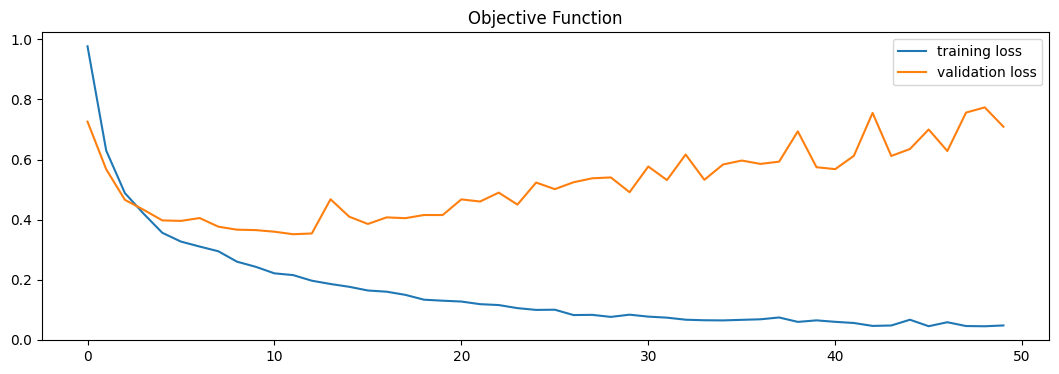

In [28]:
plt.figure(figsize=(13, 4))

plt.title('Objective Function')
plt.plot(train_loss, label = 'training loss')
plt.plot(val_loss, label = 'validation loss')

plt.legend()

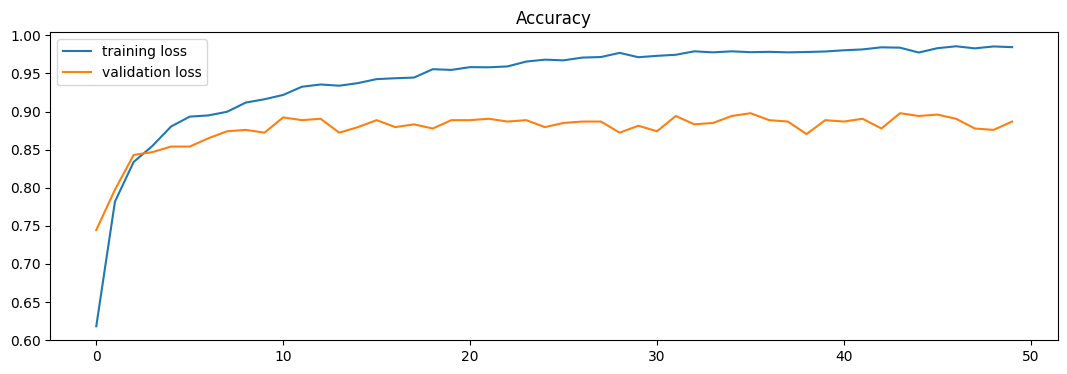

In [30]:
plt.figure(figsize=(13, 4))

plt.title('Accuracy')
plt.plot(train_acc, label = 'training loss')
plt.plot(val_acc, label = 'validation loss')

plt.legend()

In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv('../checkpoints/task01/history01.csv')

### 3.2. Model prediction

In [ ]:
model = TransformerClassifier(
    vocab_size=len(vocab.stoi),
    d_model=128,
    nhead=4,
    num_layers=3,
    num_classes=len(le.classes_),
    max_len=300,
    # enable_nested_tensor=False
)

checkpoint_path = '../checkpoints/task01/model01.pth'
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)

In [37]:
model.load_state_dict(state_dict)
model.to(device)
model.eval()

TransformerClassifier(
  (embedding): Embedding(3318, 128, padding_idx=0)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout

In [40]:
def predict(model, data_loader, device, vocab, label_encoder=None):
    model.eval() 
    
    preds = []
    actuals = []
    pad_idx = vocab.pad_index
    
    print("Đang thực hiện dự đoán...")
    with torch.no_grad():
        for src, targets in tqdm(data_loader):
            src = src.to(device)
            targets = targets.to(device)

            src_key_padding_mask = (src == pad_idx)
            outputs = model(src, src_key_padding_mask=src_key_padding_mask)
            _, predicted_indices = torch.max(outputs, 1)
            preds.extend(predicted_indices.cpu().tolist())
            actuals.extend(targets.cpu().tolist())

    if label_encoder is not None:
        preds = label_encoder.inverse_transform(preds)
        actuals = label_encoder.inverse_transform(actuals)
        
    return preds, actuals

In [42]:
pred, act = predict(
    model=model,
    data_loader=test_loader,
    device=device,
    vocab=vocab
)

Đang thực hiện dự đoán...


100%|██████████| 18/18 [00:00<00:00, 74.71it/s]


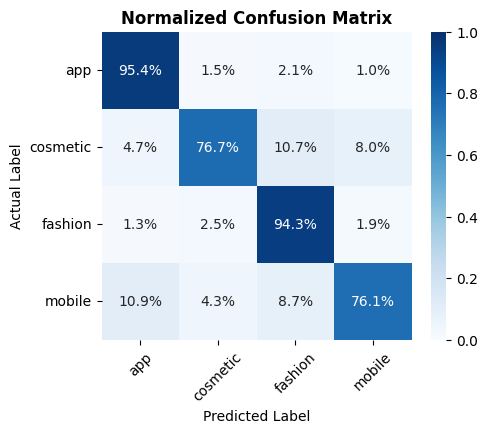

In [50]:
cm = confusion_matrix(act, pred)
cm_rate = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rate,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    vmin=0, vmax=1
)

plt.title('Normalized Confusion Matrix', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [54]:
report_dict = classification_report(
    act, 
    pred, 
    target_names=le.classes_, 
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df['support'] = report_df['support'].astype(int)
report_df = report_df.round(4)
print(report_df)

              precision  recall  f1-score  support
app              0.9296  0.9536    0.9415      194
cosmetic         0.9274  0.7667    0.8394      150
fashion          0.8621  0.9434    0.9009      159
mobile           0.6731  0.7609    0.7143       46
accuracy         0.8834  0.8834    0.8834        0
macro avg        0.8481  0.8561    0.8490      549
weighted avg     0.8880  0.8834    0.8828      549
